# Quy trình làm sạch dữ liệu sách

Notebook này thay thế luồng tiền xử lý dạng script và trình bày từng bước làm sạch dữ liệu một cách minh bạch, dễ theo dõi để phục vụ trực quan hóa.

## Mục tiêu chính
- Nạp dữ liệu thô từ `data/raw/book_dataset.csv`.
- Làm sạch và chuẩn hóa các cột số, cột văn bản, cột boolean và cột thời gian quan trọng.
- Xử lý các trường đa giá trị (đặc biệt là `authors`) thành dạng dễ phân tích.
- Loại các cột chỉ có một giá trị duy nhất.
- Loại các dòng thiếu dữ liệu ở các cột trọng yếu cho trực quan hóa.
- Xuất dữ liệu đã làm sạch và báo cáo xử lý.

In [8]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")


def find_project_root(start: Path) -> Path:
    """Find project root by locating data/raw/book_dataset.csv upward from cwd."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw" / "book_dataset.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/raw/book_dataset.csv")


PROJECT_ROOT = find_project_root(Path.cwd())
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "book_dataset.csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data path: {RAW_PATH}")

Project root: D:\Hp\Documents\University\Nam 3\HKII\DV\Prj1\data-visualization-lab1
Raw data path: D:\Hp\Documents\University\Nam 3\HKII\DV\Prj1\data-visualization-lab1\data\raw\book_dataset.csv


## 1) Nạp dữ liệu thô và kiểm tra nhanh

Bước đầu tiên là đọc file CSV gốc và xem nhanh kích thước, danh sách cột và tình trạng thiếu dữ liệu để hiểu trạng thái ban đầu của dữ liệu trước khi làm sạch.

In [9]:
df_raw = pd.read_csv(RAW_PATH, low_memory=False)

print(f"Raw shape: {df_raw.shape}")
print("\nColumns:")
print(df_raw.columns.tolist())

missing_top = df_raw.isna().sum().sort_values(ascending=False).head(15)
print("\nTop missing columns (raw):")
print(missing_top)

df_raw.head(3)

Raw shape: (132955, 26)

Columns:
['id', 'name', 'price', 'list_price', 'discount_rate', 'rating_average', 'review_count', 'all_time_quantity_sold', 'authors', 'publisher_vn', 'manufacturer', 'isbn13', 'book_cover', 'number_of_page', 'publication_date', 'current_seller_name', 'inventory_status', 'stock', 'has_freeship', 'is_authentic', 'has_return_policy', 'cat_level_1', 'cat_level_2', 'cat_level_3', 'cat_level_4', 'cat_level_5']

Top missing columns (raw):
isbn13                 118450
cat_level_5             85931
publication_date        77844
number_of_page          66866
authors                 46694
book_cover              46084
manufacturer             6372
cat_level_4              2051
publisher_vn              659
current_seller_name       376
stock                     376
cat_level_3                 0
cat_level_2                 0
cat_level_1                 0
has_return_policy           0
dtype: int64


,id,name,price,list_price,discount_rate,rating_average,review_count,all_time_quantity_sold,authors,publisher_vn,manufacturer,isbn13,book_cover,number_of_page,publication_date,current_seller_name,inventory_status,stock,has_freeship,is_authentic,has_return_policy,cat_level_1,cat_level_2,cat_level_3,cat_level_4,cat_level_5
0,26114399,"Sách Nóng Giận Là Bản Năng , Tĩnh Lặng Là Bản ...",83930,109000,23,4.80,7257,75282,Tống Mặc,Skybooks,Nhà Xuất Bản Thế Giới,NaN,Bìa mềm,264,1/8/2019,Tiki Trading,available,"1,000.00",False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-ky-nang-song,sach-ky-nang-song,NaN
1,52789367,Sách Nhà Giả Kim (Tái Bản),78000,95000,18,5.00,6076,39825,Paulo Coelho,Nhã Nam,Nhà Xuất Bản Hà Nội,NaN,Bìa mềm,228,4/1/2020,Tiki Trading,available,"1,000.00",False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-van-hoc,tac-pham-kinh-dien,tac-pham-kinh-dien-nuoc-ngoai
2,109017985,"Sách Thiên Tài Bên Trái, Kẻ Điên Bên Phải (Tái...",137830,179000,23,4.80,5492,27187,Cao Minh,Vibooks,Nhà Xuất Bản Thế Giới,NaN,Bìa mềm,424,6/1/2021,Tiki Trading,available,"1,000.00",False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-van-hoc,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-nuoc-ngoai


## 2) Khai báo quy tắc làm sạch và hàm hỗ trợ

Phần này định nghĩa:
- Các cột trọng yếu phục vụ trực quan hóa.
- Quy tắc chuyển kiểu dữ liệu.
- Quy tắc chuẩn hóa text và boolean.
- Logic tách nhiều tác giả trong một trường.
- Các hàm tiện ích dùng chung trong toàn bộ pipeline.

In [10]:
# Columns requested for downstream visualizations.
CRITICAL_COLUMNS = [
    "name",
    "price",
    "list_price",
    "discount_rate",
    "rating_average",
    "review_count",
    "all_time_quantity_sold",
    "authors",
    "current_seller_name",
    "has_freeship",
    "cat_level_2",
    "cat_level_3",
    "number_of_page",
    "publication_year",
]

NUMERIC_COLUMNS = [
    "price",
    "list_price",
    "discount_rate",
    "rating_average",
    "review_count",
    "all_time_quantity_sold",
    "number_of_page",
]

BOOL_COLUMNS = ["has_freeship", "is_authentic", "has_return_policy"]

# Configurable range filter for page count.
PAGE_RANGE_COLUMN = "number_of_page"
ENABLE_PAGE_RANGE_FILTER = True
PAGE_RANGE_MIN = 1
PAGE_RANGE_MAX = 5000


def normalize_empty_strings(df: pd.DataFrame) -> pd.DataFrame:
    object_cols = df.select_dtypes(include=["object"]).columns.tolist()
    for col in object_cols:
        df[col] = df[col].astype("string").str.strip()
    if object_cols:
        df[object_cols] = df[object_cols].replace(r"^\s*$", pd.NA, regex=True)
    return df


def normalize_boolean(value):
    if pd.isna(value):
        return pd.NA
    if isinstance(value, bool):
        return value
    if isinstance(value, (int, float)):
        if value == 1:
            return True
        if value == 0:
            return False
    text = str(value).strip().lower()
    if text in {"true", "1", "yes", "y", "t"}:
        return True
    if text in {"false", "0", "no", "n", "f"}:
        return False
    return pd.NA


def split_authors(text: str) -> list[str]:
    """Split author string into multiple authors for long-form analysis."""
    if pd.isna(text):
        return []
    normalized = str(text)
    normalized = re.sub(r"\s+", " ", normalized).strip()
    parts = re.split(r"\s*(?:,|;|/|&|\band\b|\bvà\b)\s*", normalized, flags=re.IGNORECASE)
    parts = [p.strip() for p in parts if p and p.strip()]

    # Remove duplicates while keeping original order.
    seen = set()
    unique_parts = []
    for p in parts:
        key = p.lower()
        if key not in seen:
            seen.add(key)
            unique_parts.append(p)
    return unique_parts


print("Rule setup complete.")
print("Critical columns:", CRITICAL_COLUMNS)
print(
    f"Page-range filter: {ENABLE_PAGE_RANGE_FILTER} | "
    f"{PAGE_RANGE_COLUMN} in [{PAGE_RANGE_MIN}, {PAGE_RANGE_MAX}]"
)

Rule setup complete.
Critical columns: ['name', 'price', 'list_price', 'discount_rate', 'rating_average', 'review_count', 'all_time_quantity_sold', 'authors', 'current_seller_name', 'has_freeship', 'cat_level_2', 'cat_level_3', 'number_of_page', 'publication_year']
Page-range filter: True | number_of_page in [1, 5000]


## 3) Làm sạch và chuẩn hóa dữ liệu

Bước này thực hiện pipeline tiền xử lý dữ liệu nhằm đảm bảo tính nhất quán, hợp lệ và sẵn sàng cho phân tích/mô hình:

**Các bước chính:**
1. **Loại trùng dữ liệu**  
   - Xóa các bản ghi trùng theo `id` (nếu có) hoặc toàn bộ dòng.

2. **Chuẩn hóa dữ liệu dạng text & boolean**  
   - Loại bỏ khoảng trắng, chuẩn hóa chữ thường.  
   - Đồng nhất giá trị boolean.

3. **Chuyển kiểu dữ liệu**  
   - Ép kiểu các cột số (`numeric`).  
   - Chuyển `publication_date` sang datetime và tạo `publication_year`.

4. **Chuẩn hóa danh mục & thông tin tác giả**  
   - Đồng nhất các level category (`cat_level_*`).  
   - Tách danh sách tác giả → tạo `author_count`, `primary_author`.

5. **Áp dụng ràng buộc dữ liệu (data constraints)**  
   - Loại bỏ giá trị âm hoặc ngoài phạm vi hợp lệ.  
   - Chuẩn hóa `rating_average` ∈ [0, 5], `discount_rate` ∈ [0, 100].  
   - Điều chỉnh `list_price ≥ price`.

6. **Xử lý missing values**  
   - Điền 0 cho các biến: `rating_average`, `review_count`, `all_time_quantity_sold`.

7. **Lọc dữ liệu theo domain (tùy chọn)**  
   - Giữ các bản ghi có `number_of_page` nằm trong khoảng hợp lý.

8. **Loại bỏ cột không có thông tin (constant features)**  
   - Xóa các cột chỉ có 1 giá trị (2 lần: trước và sau khi lọc dữ liệu).

9. **Lọc dữ liệu quan trọng**  
   - Loại các dòng thiếu giá trị ở các cột critical.

In [11]:
df = df_raw.copy()

rows_before = len(df)

# Remove duplicate products by id if available.
if "id" in df.columns:
    df = df.drop_duplicates(subset=["id"], keep="first")
else:
    df = df.drop_duplicates(keep="first")

# Normalize empty strings and trim text columns.
df = normalize_empty_strings(df)

# Convert numeric columns.
for col in NUMERIC_COLUMNS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert booleans.
for col in BOOL_COLUMNS:
    if col in df.columns:
        df[col] = df[col].map(normalize_boolean).astype("boolean")

# Datetime conversion + publication year.
if "publication_date" in df.columns:
    df["publication_date"] = pd.to_datetime(df["publication_date"], errors="coerce")
    df["publication_year"] = df["publication_date"].dt.year.astype("Int64")

# Standardize seller text to reduce duplicates in grouping.
if "current_seller_name" in df.columns:
    df["current_seller_name"] = (
        df["current_seller_name"].astype("string").str.strip().str.lower()
    )

# Standardize category labels.
for cat_col in ["cat_level_1", "cat_level_2", "cat_level_3", "cat_level_4", "cat_level_5"]:
    if cat_col in df.columns:
        df[cat_col] = df[cat_col].astype("string").str.strip().str.lower()

# Parse multi-author field and create helper features.
if "authors" in df.columns:
    df["authors_tokens"] = df["authors"].apply(split_authors)
    df["author_count"] = df["authors_tokens"].apply(len).astype("Int64")
    df["primary_author"] = df["authors_tokens"].apply(lambda x: x[0] if len(x) > 0 else pd.NA)
    df["authors_list"] = df["authors_tokens"].apply(lambda x: " | ".join(x) if len(x) > 0 else pd.NA)

# Basic domain constraints.
for col in ["price", "list_price", "discount_rate", "review_count", "all_time_quantity_sold", "number_of_page"]:
    if col in df.columns:
        df.loc[df[col] < 0, col] = pd.NA

if "rating_average" in df.columns:
    df.loc[(df["rating_average"] < 0) | (df["rating_average"] > 5), "rating_average"] = pd.NA

if "discount_rate" in df.columns:
    df.loc[(df["discount_rate"] < 0) | (df["discount_rate"] > 100), "discount_rate"] = pd.NA

# If list_price is below price, align list_price to price.
if {"price", "list_price"}.issubset(df.columns):
    invalid_price_mask = df["price"].notna() & df["list_price"].notna() & (df["list_price"] < df["price"])
    df.loc[invalid_price_mask, "list_price"] = df.loc[invalid_price_mask, "price"]

# Apply optional page-range filter on page count.
rows_before_page_filter = len(df)
if ENABLE_PAGE_RANGE_FILTER and PAGE_RANGE_COLUMN in df.columns:
    if PAGE_RANGE_MIN > PAGE_RANGE_MAX:
        raise ValueError("PAGE_RANGE_MIN must be less than or equal to PAGE_RANGE_MAX.")
    page_mask = df[PAGE_RANGE_COLUMN].between(PAGE_RANGE_MIN, PAGE_RANGE_MAX, inclusive="both")
    df = df.loc[page_mask].copy()
    page_filter_desc = f"{PAGE_RANGE_COLUMN} in [{PAGE_RANGE_MIN}, {PAGE_RANGE_MAX}]"
else:
    page_filter_desc = "disabled or column missing"
rows_after_page_filter = len(df)

# Requested imputation strategy for rating and review metrics (safe for plotting libs).
for col in ["rating_average", "review_count", "all_time_quantity_sold"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Create aliases asked by the team.
if "rating_average" in df.columns:
    df["rating_rate"] = df["rating_average"]
if "current_seller_name" in df.columns:
    df["current_seller"] = df["current_seller_name"]


def unique_count_safe(series: pd.Series) -> int:
    """Handle unhashable values (like list) when counting unique values."""
    try:
        return int(series.nunique(dropna=False))
    except TypeError:
        normalized = series.apply(lambda x: tuple(x) if isinstance(x, list) else x)
        return int(normalized.nunique(dropna=False))


# Drop columns that contain only one unique value (including NaN as a value).
constant_columns = [
    col for col in df.columns
    if unique_count_safe(df[col]) <= 1
]
df = df.drop(columns=constant_columns)

# Keep only critical columns that still exist after cleaning.
critical_existing = [col for col in CRITICAL_COLUMNS if col in df.columns]

rows_before_critical_drop = len(df)
df_clean = df.dropna(subset=critical_existing).copy()
rows_after_critical_drop = len(df_clean)

# Drop single-value columns again after row-level filtering.
post_clean_constant_columns = [
    col for col in df_clean.columns
    if unique_count_safe(df_clean[col]) <= 1
]
df_clean = df_clean.drop(columns=post_clean_constant_columns)

print(f"Rows before cleaning: {rows_before}")
print(f"Rows after page-range filter: {rows_after_page_filter}")
print(f"Dropped rows by page-range filter: {rows_before_page_filter - rows_after_page_filter}")
print(f"Page-range filter config: {page_filter_desc}")
print(f"Rows before critical drop: {rows_before_critical_drop}")
print(f"Rows after critical drop: {rows_after_critical_drop}")
print(f"Dropped rows by critical-null filter: {rows_before_critical_drop - rows_after_critical_drop}")
print(f"Dropped single-value columns (pass 1): {len(constant_columns)}")
print(f"Dropped single-value columns (pass 2): {len(post_clean_constant_columns)}")

{
    "single_value_pass1_sample": constant_columns[:20],
    "single_value_pass2_sample": post_clean_constant_columns[:20],
}

Rows before cleaning: 132955
Rows after page-range filter: 65987
Dropped rows by page-range filter: 66968
Page-range filter config: number_of_page in [1, 5000]
Rows before critical drop: 65987
Rows after critical drop: 36763
Dropped rows by critical-null filter: 29224
Dropped single-value columns (pass 1): 2
Dropped single-value columns (pass 2): 0


{'single_value_pass1_sample': ['stock', 'cat_level_1'],
 'single_value_pass2_sample': []}

## 3.5) Phát hiện ngoại lai (Outlier Detection)

Sử dụng phương pháp **IQR** để phát hiện và thống kê ngoại lai trong các cột số sau khi làm sạch.

- Cận dưới: Q1 − 1.5 × IQR
- Cận trên: Q3 + 1.5 × IQR

**Chiến lược xử lý:** Giữ nguyên toàn bộ outliers — không capping.  
Lý do: đây là dữ liệu kinh doanh thực tế (giá sách, lượt bán); các giá trị cực đại (sách bestseller, sách cao cấp) là có ý nghĩa và không nên bị bóp méo.  
Khi trực quan hóa, nhóm em sử dụng **log scale** tại tầng dashboard để xử lý phân phối lệch phải thay vì sửa dữ liệu gốc.

=== Thống kê ngoại lai (IQR method) ===
Cột                                  Q1         Q3        IQR     Cận dưới     Cận trên  Ngoại lai       %
-----------------------------------------------------------------------------------------------
price                           75900.0   189000.0   113100.0     -93750.0     358650.0      2,322    6.3%
list_price                      88000.0   207500.0   119500.0     -91250.0     386750.0      2,318    6.3%
discount_rate                       0.0       20.0       20.0        -30.0         50.0         56    0.2%
review_count                        0.0        3.0        3.0         -4.5          7.5      6,255   17.0%
all_time_quantity_sold              0.0       40.0       40.0        -60.0        100.0      5,602   15.2%
number_of_page                    172.0      392.0      220.0       -158.0        722.0      1,572    4.3%
rating_average                      0.0        5.0        5.0         -7.5         12.5          0    0.0%


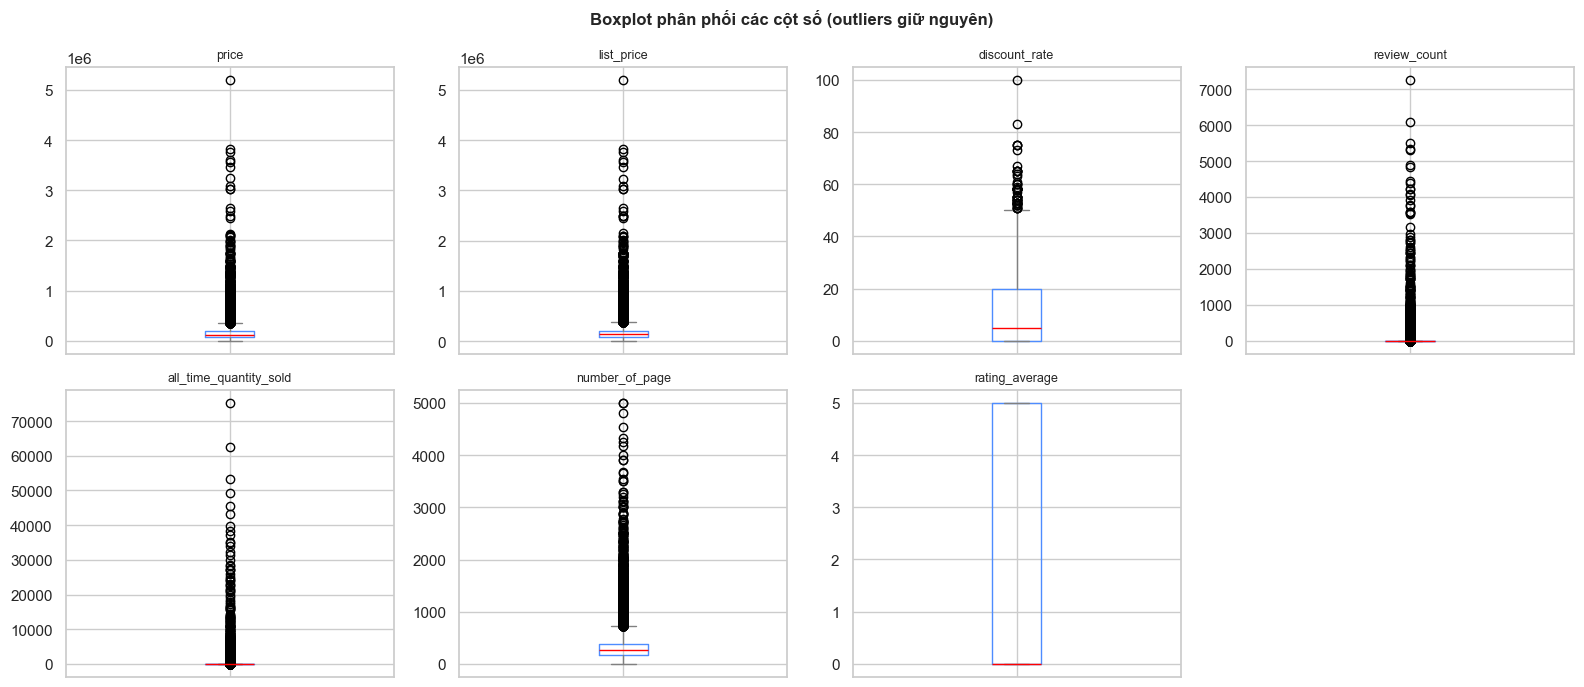

In [12]:
OUTLIER_COLS = ['price', 'list_price', 'discount_rate', 'review_count',
                'all_time_quantity_sold', 'number_of_page', 'rating_average']

# --- Bảng thống kê IQR ---
print('=== Thống kê ngoại lai (IQR method) ===')
print(f"{'Cột':<28} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Cận dưới':>12} {'Cận trên':>12} {'Ngoại lai':>10} {'%':>7}")
print('-' * 95)
outlier_report = {}
for col in OUTLIER_COLS:
    if col not in df_clean.columns:
        continue
    s = df_clean[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lower) | (s > upper)).sum())
    pct = n_out / len(s) * 100
    outlier_report[col] = dict(Q1=q1, Q3=q3, IQR=iqr, lower=lower,
                                upper=upper, n_outliers=n_out, pct=pct)
    print(f'{col:<28} {q1:>10.1f} {q3:>10.1f} {iqr:>10.1f} '
          f'{lower:>12.1f} {upper:>12.1f} {n_out:>10,} {pct:>6.1f}%')

# --- Boxplot ---
_oc = [c for c in OUTLIER_COLS if c in df_clean.columns]
ncols, nrows = 4, -(-len(_oc) // 4)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()
bp = {'boxes': '#4e8cff', 'whiskers': 'gray', 'caps': 'gray', 'medians': 'red'}
for i, col in enumerate(_oc):
    df_clean[col].dropna().plot.box(ax=axes[i], color=bp, vert=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis='x', labelbottom=False)
for j in range(len(_oc), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplot phân phối các cột số (outliers giữ nguyên)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("=== Thống kê mô tả sau khi làm sạch (outliers giữ nguyên) ===")
_report_cols = [c for c in OUTLIER_COLS if c in df_clean.columns]
df_clean[_report_cols].describe().T[["mean", "50%", "75%", "max"]].round(1)

=== Thống kê mô tả sau khi làm sạch (outliers giữ nguyên) ===


,mean,50%,75%,max
price,"158,214.00","120,000.00","189,000.00","5,200,000.00"
list_price,"175,804.93","139,000.00","207,500.00","5,200,000.00"
discount_rate,10.56,5.00,20.00,100.00
review_count,17.91,0.00,3.00,"7,257.00"
all_time_quantity_sold,152.29,4.00,40.00,"75,282.00"
number_of_page,311.99,272.00,392.00,"5,000.00"
rating_average,2.04,0.00,5.00,5.00


## 4) Tạo bảng tác giả dạng long (mở rộng dữ liệu đa giá trị)

Cột `authors` chứa nhiều tác giả trong một bản ghi (multi-value), gây khó khăn cho việc phân tích trực tiếp.  
Vì vậy, cần chuyển đổi dữ liệu sang dạng **long format**.

**Cách thực hiện:**
- Tách danh sách tác giả thành từng phần tử (`authors_tokens`)
- Sử dụng `explode()` để biến mỗi tác giả thành một dòng riêng
- Làm sạch dữ liệu (loại bỏ giá trị null, chuỗi rỗng)

**Kết quả:**
- Mỗi dòng đại diện cho một cặp **(sách – tác giả)**
- Dễ dàng thực hiện các phân tích như:
  - Top tác giả theo số lượng sách
  - Tổng doanh số theo tác giả
  - Phân tích đóng góp của từng tác giả

**Ý nghĩa:**
- Chuẩn hóa dữ liệu đa giá trị về dạng có thể phân tích (tidy data)
- Hỗ trợ tốt hơn cho EDA và trực quan hóa

In [14]:
if "authors_tokens" in df_clean.columns:
    base_cols = [col for col in ["id", "name", "cat_level_2", "cat_level_3", "all_time_quantity_sold"] if col in df_clean.columns]
    authors_long = (
        df_clean[base_cols + ["authors_tokens"]]
        .explode("authors_tokens")
        .rename(columns={"authors_tokens": "author"})
        .dropna(subset=["author"])
    )
    authors_long["author"] = authors_long["author"].astype("string").str.strip()
    authors_long = authors_long[authors_long["author"].ne("")]
else:
    authors_long = pd.DataFrame()

print(f"Author-long rows: {len(authors_long)}")
authors_long.head(5)

Author-long rows: 41766


,id,name,cat_level_2,cat_level_3,all_time_quantity_sold,author
0,26114399,"Sách Nóng Giận Là Bản Năng , Tĩnh Lặng Là Bản ...",sach-truyen-tieng-viet,sach-ky-nang-song,"75,282.00",Tống Mặc
1,52789367,Sách Nhà Giả Kim (Tái Bản),sach-truyen-tieng-viet,sach-van-hoc,"39,825.00",Paulo Coelho
2,109017985,"Sách Thiên Tài Bên Trái, Kẻ Điên Bên Phải (Tái...",sach-truyen-tieng-viet,sach-van-hoc,"27,187.00",Cao Minh
3,278277832,Sách Vui Vẻ Không Quạu Nha - Tản Văn,sach-truyen-tieng-viet,sach-van-hoc,13.00,Ở Đây Zui Nè
4,71345381,Sách Thay Đổi Cuộc Sống Với Nhân Số Học - Lê Đ...,sach-truyen-tieng-viet,sach-ky-nang-song,"31,431.00",David A. Phillips


## 5) Xuất dữ liệu đã làm sạch và báo cáo xử lý

Ta sẽ lưu:
- Bảng dữ liệu chính đã làm sạch để trực quan hóa.
- Bảng tác giả dạng long phục vụ phân tích đa tác giả.
- Báo cáo JSON gồm số dòng, cột bị loại và các chỉ số kiểm tra chất lượng dữ liệu.

In [15]:
main_output_path = OUTPUT_DIR / "book_dataset_clean_notebook.csv"
author_output_path = OUTPUT_DIR / "book_dataset_authors_long_notebook.csv"
report_output_path = OUTPUT_DIR / "book_dataset_clean_notebook_report.json"

# Drop list column before CSV export to keep file format simple.
df_export = df_clean.copy()
if "authors_tokens" in df_export.columns:
    df_export = df_export.drop(columns=["authors_tokens"])

# Prioritize column order for downstream users.
preferred_order = [
    "id",
    "name",
    "authors",
    "authors_list",
    "primary_author",
    "author_count",
    "price",
    "list_price",
    "discount_rate",
    "rating_average",
    "rating_rate",
    "review_count",
    "all_time_quantity_sold",
    "current_seller_name",
    "current_seller",
    "has_freeship",
    "cat_level_2",
    "cat_level_3",
    "number_of_page",
    "publication_date",
    "publication_year",
]
existing_preferred = [c for c in preferred_order if c in df_export.columns]
remaining_cols = [c for c in df_export.columns if c not in existing_preferred]
df_export = df_export[existing_preferred + remaining_cols]

# Final single-value drop to guarantee exported data has no constant fields.
final_constant_columns = [
    col for col in df_export.columns
    if unique_count_safe(df_export[col]) <= 1
]
if final_constant_columns:
    df_export = df_export.drop(columns=final_constant_columns)

df_export.to_csv(main_output_path, index=False, encoding="utf-8-sig")
authors_long.to_csv(author_output_path, index=False, encoding="utf-8-sig")

missing_after = {col: int(df_export[col].isna().sum()) for col in CRITICAL_COLUMNS if col in df_export.columns}
all_single_value_columns = sorted(
    set(constant_columns)
    | set(post_clean_constant_columns)
    | set(final_constant_columns)
)

report = {
    "input_path": str(RAW_PATH),
    "main_output_path": str(main_output_path),
    "author_output_path": str(author_output_path),
    "raw_rows": int(len(df_raw)),
    "rows_after_cleaning": int(len(df_export)),
    "rows_dropped_by_page_range_filter": int(rows_before_page_filter - rows_after_page_filter),
    "rows_dropped_by_critical_missing": int(rows_before_critical_drop - rows_after_critical_drop),
    "page_range_filter": {
        "enabled": ENABLE_PAGE_RANGE_FILTER,
        "column": PAGE_RANGE_COLUMN,
        "min": PAGE_RANGE_MIN,
        "max": PAGE_RANGE_MAX,
    },
    "dropped_single_value_columns_pass1": constant_columns,
    "dropped_single_value_columns_pass2": post_clean_constant_columns,
    "dropped_single_value_columns_final_export": final_constant_columns,
    "dropped_single_value_columns": all_single_value_columns,
    "critical_columns_used": [col for col in CRITICAL_COLUMNS if col in df_export.columns],
    "critical_missing_after_cleaning": missing_after,
    "output_columns": df_export.columns.tolist(),
}

report_output_path.write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Main dataset saved to: {main_output_path}")
print(f"Author-long dataset saved to: {author_output_path}")
print(f"Report saved to: {report_output_path}")
print(f"Final shape: {df_export.shape}")
print(f"Single-value columns dropped (all passes): {len(all_single_value_columns)}")

Main dataset saved to: D:\Hp\Documents\University\Nam 3\HKII\DV\Prj1\data-visualization-lab1\data\processed\book_dataset_clean_notebook.csv
Author-long dataset saved to: D:\Hp\Documents\University\Nam 3\HKII\DV\Prj1\data-visualization-lab1\data\processed\book_dataset_authors_long_notebook.csv
Report saved to: D:\Hp\Documents\University\Nam 3\HKII\DV\Prj1\data-visualization-lab1\data\processed\book_dataset_clean_notebook_report.json
Final shape: (36763, 30)
Single-value columns dropped (all passes): 2


## 6) Kiểm tra sau làm sạch
Bước kiểm tra cuối cùng đảm bảo các cột bắt buộc còn tồn tại và không còn thiếu dữ liệu sau khi lọc.

In [16]:
missing_summary = (
    df_export[[c for c in CRITICAL_COLUMNS if c in df_export.columns]]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("Critical-column missing values after cleaning:")
print(missing_summary)

print("\nSample rows from cleaned dataset:")
df_export.head(5)

Critical-column missing values after cleaning:
name                      0
price                     0
list_price                0
discount_rate             0
rating_average            0
review_count              0
all_time_quantity_sold    0
authors                   0
current_seller_name       0
has_freeship              0
cat_level_2               0
cat_level_3               0
number_of_page            0
publication_year          0
dtype: int64

Sample rows from cleaned dataset:


,id,name,authors,authors_list,primary_author,author_count,price,list_price,discount_rate,rating_average,rating_rate,review_count,all_time_quantity_sold,current_seller_name,current_seller,has_freeship,cat_level_2,cat_level_3,number_of_page,publication_date,publication_year,publisher_vn,manufacturer,isbn13,book_cover,inventory_status,is_authentic,has_return_policy,cat_level_4,cat_level_5
0,26114399,"Sách Nóng Giận Là Bản Năng , Tĩnh Lặng Là Bản ...",Tống Mặc,Tống Mặc,Tống Mặc,1,"83,930.00","109,000.00",23.00,4.80,4.80,"7,257.00","75,282.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-ky-nang-song,264,2019-01-08,2019,Skybooks,Nhà Xuất Bản Thế Giới,<NA>,Bìa mềm,available,True,True,sach-ky-nang-song,<NA>
1,52789367,Sách Nhà Giả Kim (Tái Bản),Paulo Coelho,Paulo Coelho,Paulo Coelho,1,"78,000.00","95,000.00",18.00,5.00,5.00,"6,076.00","39,825.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-van-hoc,228,2020-04-01,2020,Nhã Nam,Nhà Xuất Bản Hà Nội,<NA>,Bìa mềm,available,True,True,tac-pham-kinh-dien,tac-pham-kinh-dien-nuoc-ngoai
2,109017985,"Sách Thiên Tài Bên Trái, Kẻ Điên Bên Phải (Tái...",Cao Minh,Cao Minh,Cao Minh,1,"137,830.00","179,000.00",23.00,4.80,4.80,"5,492.00","27,187.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-van-hoc,424,2021-06-01,2021,Vibooks,Nhà Xuất Bản Thế Giới,<NA>,Bìa mềm,available,True,True,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-nuoc-ngoai
3,278277832,Sách Vui Vẻ Không Quạu Nha - Tản Văn,Ở Đây Zui Nè,Ở Đây Zui Nè,Ở Đây Zui Nè,1,"60,830.00","79,000.00",23.00,4.70,4.70,"5,338.00",13.00,tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-van-hoc,280,2020-03-01,2020,Skybooks,Nhà Xuất Bản Phụ Nữ,<NA>,Bìa mềm,available,True,True,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-viet-nam
4,71345381,Sách Thay Đổi Cuộc Sống Với Nhân Số Học - Lê Đ...,David A. Phillips,David A. Phillips,David A. Phillips,1,"173,462.00","248,000.00",30.00,4.80,4.80,"5,294.00","31,431.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-ky-nang-song,342,2020-10-01,2020,First News - Trí Việt,Nhà Xuất Bản Tổng hợp TP.HCM,<NA>,Bìa gập,available,True,True,sach-ky-nang-song,<NA>
